In [1]:
#Este trabalho tem como objetivo reproduzir a FIG. 13 do artigo DESI DR2, página 26.
#Artigo principal: "DESI DR2 Results II: Measurements of Baryon Acoustic Oscillations and Cosmological Constraints" (https://arxiv.org/abs/2503.14738)
#Artigo citado ao longo do código: "Planck 2018 results. VI. Cosmological parameters" (http://arxiv.org/abs/1807.06209)

In [2]:
# CAMB LateDE
import numpy as np
import matplotlib.pyplot as plt
import camb, os, sys

#Check which CAMB is installed
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.0 installed at C:\Users\Paula\anaconda3\Lib\site-packages\camb


In [3]:
c = 299792.458  # km/s

In [4]:
#Fiducial: ΛCDM do Planck 2018

latede_cosmology_fid = camb.set_params(# Background
                            H0 = 67.27, ombh2=0.02236, omch2=0.12091, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [5]:
# Executar o cálculo
results = camb.get_results(latede_cosmology_fid)

# Intervalo de redshift
z_fid = np.linspace(0.1, 3, 50)

# Distâncias e parâmetros derivados
DA_fid = results.angular_diameter_distance(z_fid)  # [Mpc]
H_fid  = results.hubble_parameter(z_fid)            # [km/s/Mpc]
r_s_fid      = results.get_derived_params()['rdrag']        # [Mpc]

DM_fid = (results.comoving_radial_distance(z_fid))

# Distâncias normalizadas
DMfid = DM_fid / r_s_fid
DHfid = (c / H_fid) / r_s_fid
DVfid = (( DM_fid**2 * (c*z_fid)/H_fid )**(1/3)) / r_s_fid  

In [6]:
#Gráfico para D_V

#DESI com barras de erro (a)
#ΛCDM: CMB (b)
#ΛCDM: DESY5 (c)
#ΛCDM: DESI (d)
#ΛCDM: DESI+CMB (e)

z_DV = [0.295]
DV = [7.94167639]
err_DV = [0.07609196]


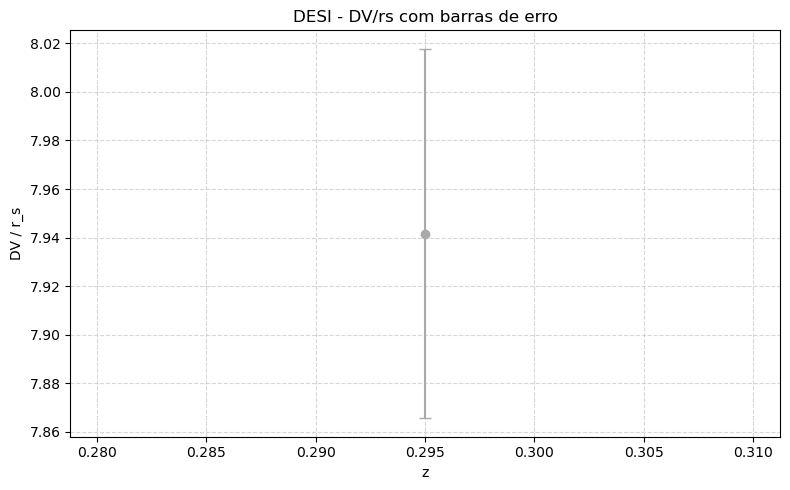

In [7]:
#DESI com barras de erro (a)

import numpy as np
import matplotlib.pyplot as plt

mean_file = r"C:\Users\Paula\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt"
cov_file  = r"C:\Users\Paula\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt"

# -------------------------------------------
# 1. Carregar matriz de covariância (13×13)
# -------------------------------------------
cov = np.loadtxt(cov_file)

# erros = sqrt da diagonal
errors = np.sqrt(np.diag(cov))

# -------------------------------------------
# 2. Carregar dados médios (lendo linha a linha)
# -------------------------------------------
data = []
with open(mean_file, "r") as f:
    for line in f:
        if not line.startswith("#"):
            z, value, quantity = line.split()
            data.append([float(z), float(value), quantity])

data = np.array(data, dtype=object)

# -------------------------------------------
# 3. Filtrar apenas DV_over_rs
# -------------------------------------------
mask_DV = data[:,2] == "DV_over_rs"

z_DV  = data[mask_DV][:,0].astype(float)   # redshift
DV    = data[mask_DV][:,1].astype(float)   # DV/rs valores
err_DV = errors[mask_DV]                   # erros correspondentes

# debug opcional:
print("z_DV =", z_DV)
print("DV =", DV)
print("err_DV =", err_DV)

# -------------------------------------------
# 4. Gráfico simples só com barras de erro
# -------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(
    z_DV, DV, 
    yerr=err_DV,
    fmt='o',
    capsize=4,
    color='darkgray',
    ecolor='darkgray',
    elinewidth=1.5,
)
plt.xlabel("z")
plt.ylabel("DV / r_s")
plt.title("DESI - DV/rs com barras de erro")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
#ΛCDM: CMB (b)

latede_cosmology_b = camb.set_params(# Background
                            H0 = 67.14, ombh2=0.02236, omch2=0.1204, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [9]:
# Executar o cálculo
results = camb.get_results(latede_cosmology_b)

# Intervalo de redshift
z_LCDM_b = np.linspace(0.1, 3, 50)

# Distâncias e parâmetros derivados
DAb_LCDM = results.angular_diameter_distance(z_LCDM_b)   # [Mpc]
Hb_LCDM  = results.hubble_parameter(z_LCDM_b)            # [km/s/Mpc]
r_s_b    = results.get_derived_params()['rdrag']         # [Mpc]

# Distância comoving radial em Mpc (não normalizada)
DM_b = results.comoving_radial_distance(z_LCDM_b)        # [Mpc]

# Distâncias normalizadas
DMb = DM_b / r_s_b                                       # D_M / r_s
DHb = (c / Hb_LCDM) / r_s_b                              # D_H / r_s
DVb = ((DM_b**2 * (c*z_LCDM_b) / Hb_LCDM)**(1/3)) / r_s_b   # D_V / r_s


In [10]:
#ΛCDM: DESY5 (c) (Não consta na TABLE V, então utilizei H_0 de Planck 2018 e Omega_m=0.36, medida estimada de acordo com o gráfico da FIG. 10 do artigo principal.)

latede_cosmology_c = camb.set_params(# Background
                            H0 = 67.36, ombh2=0.02236, omch2=0.1409, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [11]:
# Executar o cálculo
results = camb.get_results(latede_cosmology_c)

# Intervalo de redshift
z_LCDM_c = np.linspace(0.1, 3, 50)

# Distâncias e parâmetros derivados
DAc_LCDM = results.angular_diameter_distance(z_LCDM_c)   # [Mpc]
Hc_LCDM  = results.hubble_parameter(z_LCDM_c)            # [km/s/Mpc]
r_s_c    = results.get_derived_params()['rdrag']         # [Mpc]

# Distância comoving radial em Mpc (não normalizada)
DM_c = results.comoving_radial_distance(z_LCDM_c)        # [Mpc]

# Distâncias normalizadas
DMc = DM_c / r_s_c                                       # D_M / r_s
DHc = (c / Hc_LCDM) / r_s_c                              # D_H / r_s
DVc = ((DM_c**2 * (c*z_LCDM_c) / Hc_LCDM)**(1/3)) / r_s_c   # D_V / r_s

In [12]:
#ΛCDM: DESI (d) (Na falta do valor de H_0, utilizei H_0 de DESI+CMB)

latede_cosmology_d = camb.set_params(# Background
                            H0 = 68.17, ombh2=0.02236, omch2=0.1125, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [13]:
# Executar o cálculo
results = camb.get_results(latede_cosmology_d)

# Intervalo de redshift
z_LCDM_d = np.linspace(0.1, 3, 50)

# Distâncias e parâmetros derivados
DAd_LCDM = results.angular_diameter_distance(z_LCDM_d)   # [Mpc]
Hd_LCDM  = results.hubble_parameter(z_LCDM_d)            # [km/s/Mpc]
r_s_d    = results.get_derived_params()['rdrag']         # [Mpc]

# Distância comoving radial em Mpc (não normalizada)
DM_d = results.comoving_radial_distance(z_LCDM_d)        # [Mpc]

# Distâncias normalizadas
DMd = DM_d / r_s_d                                       # D_M / r_s
DHd = (c / Hd_LCDM) / r_s_d                              # D_H / r_s
DVd = ((DM_d**2 * (c*z_LCDM_d) / Hd_LCDM)**(1/3)) / r_s_d   # D_V / r_s

In [14]:
#ΛCDM: DESI+CMB (e)

latede_cosmology_e = camb.set_params(# Background
                            H0 = 68.17, ombh2=0.02236, omch2=0.1182, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [15]:
# Executar o cálculo
results = camb.get_results(latede_cosmology_e)

# Intervalo de redshift
z_LCDM_e = np.linspace(0.1, 3, 50)

# Distâncias e parâmetros derivados
DAe_LCDM = results.angular_diameter_distance(z_LCDM_e)   # [Mpc]
He_LCDM  = results.hubble_parameter(z_LCDM_e)            # [km/s/Mpc]
r_s_e    = results.get_derived_params()['rdrag']         # [Mpc]

# Distância comoving radial em Mpc (não normalizada)
DM_e = results.comoving_radial_distance(z_LCDM_e)        # [Mpc]

# Distâncias normalizadas
DMe = DM_e / r_s_e                                       # D_M / r_s
DHe = (c / He_LCDM) / r_s_e                              # D_H / r_s
DVe = ((DM_e**2 * (c*z_LCDM_e) / He_LCDM)**(1/3)) / r_s_e   # D_V / r_s

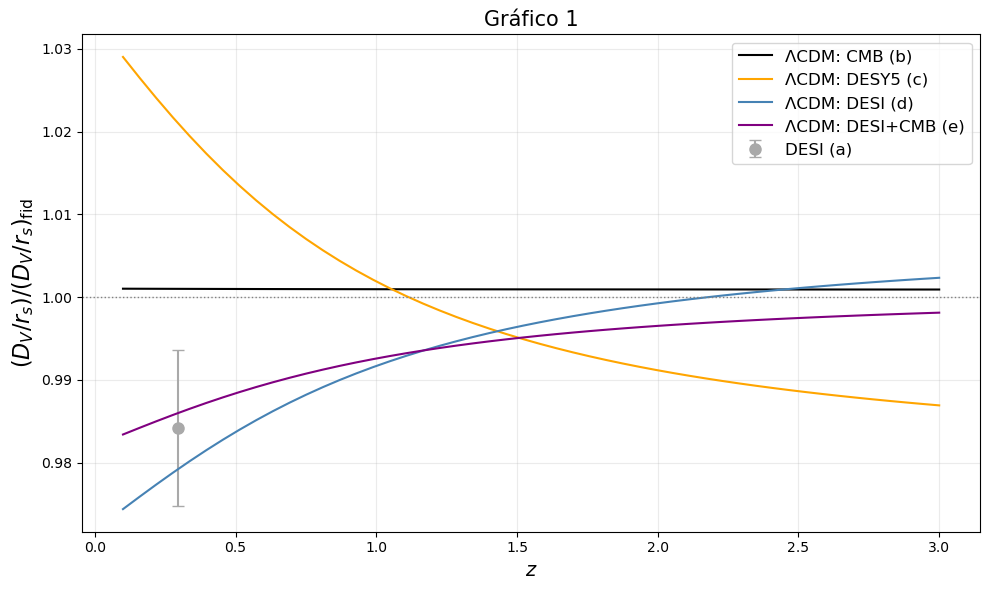

In [16]:
# Gráfico para D_V

plt.figure(figsize=(10,6))

# =======================
# 1. Normalização fiducial
# =======================

DVfid_norm = DVfid     # DVfid já é D_V / r_s (não dividir novamente)

# =======================
# 2. Cada modelo cosmológico
# =======================

# Interpolação no DV fiducial (necessária para calcular D_V no redshift correto)
DVfid_norm_interp = np.interp(z_DV, z_fid, DVfid)

# Razão DV/DV_fid
DV_ratio     = DV / DVfid_norm_interp
DV_err_ratio = err_DV / DVfid_norm_interp

# Plotar o único ponto DV
plt.errorbar(
    z_DV, DV_ratio,
    yerr=DV_err_ratio,
    fmt='o',
    color='darkgray',
    ecolor='darkgray',
    markersize=8,
    capsize=4,
    elinewidth=1.5,
    label="DESI (a)" 
)

# Modelo b
plt.plot(z_LCDM_b, DVb / DVfid_norm,
         label='ΛCDM: CMB (b)', color='black')

# Modelo c
plt.plot(z_LCDM_c, DVc / DVfid_norm,
         label='ΛCDM: DESY5 (c)', color='orange')

# Modelo d
plt.plot(z_LCDM_d, DVd / DVfid_norm,
         label='ΛCDM: DESI (d)', color='steelblue')

# Modelo e
plt.plot(z_LCDM_e, DVe / DVfid_norm,
         label='ΛCDM: DESI+CMB (e)', color='purple')

# =======================
# 3. Melhorias visuais
# =======================

plt.axhline(1.0, color='gray', linestyle=':', linewidth=1)

plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$(D_V/r_s) / (D_V/r_s)_{\rm fid}$', fontsize=16)

plt.title('Gráfico 1', fontsize=15)

plt.grid(alpha=0.25)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [17]:
#Gráfico para D_M

#DESI com barras de erro (f)
#wCDM: DESI+CMB+DESY5 (g)
#w0waCDM: DESI+DESY5 (h)
#w0waCDM: DESI+CMB+DESY5 (i)

In [18]:
#DESI com barras de erro (f) (???????????????)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.14, ombh2=0.02236, omch2=0.1204, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [19]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_w0wa = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_w0wa = results.angular_diameter_distance(z_w0wa)  # [Mpc]
H_w0wa  = results.hubble_parameter(z_w0wa)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DMf_w0wa = (1 + z_w0wa) * DA_w0wa / r_s

In [20]:
#wCDM: DESI+CMB+DESY5 (g)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.34, ombh2=0.022336, omch2=0.1180, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.961, w1 =0, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [21]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_w0wa = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_w0wa = results.angular_diameter_distance(z_w0wa)  # [Mpc]
H_w0wa  = results.hubble_parameter(z_w0wa)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DMg_w0wa = (1 + z_w0wa) * DA_w0wa / r_s

In [22]:
#w0waCDM: DESI+DESY5 (h) (Na falta do valor de H_0, utilizei H_0 de Planck 2018)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.36, ombh2=0.022336, omch2=0.1223, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.752, w1 =-0.86, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [23]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_w0wa = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_w0wa = results.angular_diameter_distance(z_w0wa)  # [Mpc]
H_w0wa  = results.hubble_parameter(z_w0wa)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DMh_w0wa = (1 + z_w0wa) * DA_w0wa / r_s

In [24]:
#w0waCDM: DESI+CMB+DESY5 (i)

latede_cosmology = camb.set_params(# Background
                            H0 = 66.74, ombh2=0.022336, omch2=0.1196, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.758, w1 =-0.82, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [25]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_w0wa = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_w0wa = results.angular_diameter_distance(z_w0wa)  # [Mpc]
H_w0wa  = results.hubble_parameter(z_w0wa)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DMi_w0wa = (1 + z_w0wa) * DA_w0wa / r_s

In [26]:
#Gráfico para D_M

plt.figure(figsize=(10,6))

# =======================
# 1. Normalização fiducial
# =======================

DVfid_norm = (DVfid / r_s_fid)

# =======================
# 2. Cada modelo cosmológico
# =======================

# DESI com barras de erro (a)
DVa_norm = DVa / r_s_a
plt.plot(z_LCDM, DVa_norm / DVfid_norm,
         label='DESI com barras de erro (a)')

# ΛCDM: CMB (b)
DVb_norm = DVb / r_s_b
plt.plot(z_LCDM, DVb_norm / DVfid_norm,
         label='ΛCDM: CMB (b)')

# ΛCDM: DESY5 (c)
DVc_norm = DVc / r_s_c
plt.plot(z_LCDM, DVc_norm / DVfid_norm,
         label='ΛCDM: DESY5 (c)')

# ΛCDM: DESI (d)
DVd_norm = DVd / r_s_d
plt.plot(z_LCDM, DVd_norm / DVfid_norm,
         label='ΛCDM: DESI (d)')

# ΛCDM: DESI+CMB (e)
DVe_norm = DVe / r_s_e
plt.plot(z_LCDM, DVe_norm / DVfid_norm,
         label='ΛCDM: DESI+CMB (e)')

# Se houver mais modelos, repetir o mesmo padrão acima


# =======================
# 3. Melhorias visuais
# =======================

plt.axhline(1.0, color='gray', linestyle=':', linewidth=1)  # linha y = 1

plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$(D_V/r_s) / (D_V/r_s)_{\rm fid}$', fontsize=16)

plt.title('Gráfico 1',
          fontsize=15)

plt.grid(alpha=0.25)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'DVa' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
#Gráfico para D_H

#DESI com barras de erro (j)
#wCDM: DESI+CMB+DESY5 (k)
#w0waCDM: DESI+DESY5 (l)
#w0waCDM: DESI+CMB+DESY5 (m)

In [ ]:
#DESI com barras de erro (j) (???????????????)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.14, ombh2=0.02236, omch2=0.1204, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [ ]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_LCDM = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_LCDM = results.angular_diameter_distance(z_LCDM)  # [Mpc]
H_LCDM  = results.hubble_parameter(z_LCDM)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DHj_LCDM = (3e5 / H_LCDM) / r_s

In [ ]:
#wCDM: DESI+CMB+DESY5 (k)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.34, ombh2=0.022336, omch2=0.1180, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.961, w1 =0, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [ ]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_LCDM = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_LCDM = results.angular_diameter_distance(z_LCDM)  # [Mpc]
H_LCDM  = results.hubble_parameter(z_LCDM)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DHk_LCDM = (3e5 / H_LCDM) / r_s

In [ ]:
#w0waCDM: DESI+DESY5 (l) (Na falta do valor de H_0, utilizei H_0 de Planck 2018)

latede_cosmology = camb.set_params(# Background
                            H0 = 67.36, ombh2=0.022336, omch2=0.1223, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.752, w1 =-0.86, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [ ]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_LCDM = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_LCDM = results.angular_diameter_distance(z_LCDM)  # [Mpc]
H_LCDM  = results.hubble_parameter(z_LCDM)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DHl_LCDM = (3e5 / H_LCDM) / r_s

In [ ]:
#w0waCDM: DESI+CMB+DESY5 (m)

latede_cosmology = camb.set_params(# Background
                            H0 = 66.74, ombh2=0.022336, omch2=0.1196, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 2,
                            w0 =-0.758, w1 =-0.82, 
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [ ]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_LCDM = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_LCDM = results.angular_diameter_distance(z_LCDM)  # [Mpc]
H_LCDM  = results.hubble_parameter(z_LCDM)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DHm_LCDM = (3e5 / H_LCDM) / r_s